# analysis_b / 03 — Latent Topic Discovery (LDA)

Unsupervised discovery of latent thematic structure in the corpus. No pre-imposed categories — topics are described purely from what emerges.

**Pipeline:** DTM → K selection (perplexity + PMI coherence) → fit final LDA → topic profiling (top words + top documents) → score/flair correlations

**Reads:** `artifacts/posts_clean.parquet`  
**Writes:** `artifacts/theta.npy`, `artifacts/phi.npy`, `artifacts/lda_vocab.json`, `artifacts/lda_model.pkl`, `artifacts/topic_labels.json`

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import textwrap
import warnings
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from scipy.sparse import csc_matrix
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

ARTIFACTS = Path('artifacts')

df = pd.read_parquet(ARTIFACTS / 'posts_clean.parquet')
print(f'Posts: {len(df):,}')
df[['text_lemma', 'score', 'year_month', 'day_idx']].head(3)

Posts: 63,305


,text_lemma,score,year_month,day_idx
0,sit outside deck hear scream second sound girl...,1,2025-05,138
1,cougar bobcat remember sound woman scream,2,2025-05,138
2,fox fox live start scream evening night sound ...,4,2025-05,138


## 1. Document-Term Matrix

In [29]:
vec = CountVectorizer(min_df=10, max_df=0.90)
dtm = vec.fit_transform(df['text_lemma'])
vocab = vec.get_feature_names_out()

print(f'DTM      : {dtm.shape[0]:,} docs × {dtm.shape[1]:,} terms')
print(f'Sparsity : {1 - dtm.nnz / (dtm.shape[0] * dtm.shape[1]):.2%}')

X_train, X_test = train_test_split(dtm, test_size=0.10, random_state=42)
print(f'Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}')

DTM      : 63,305 docs × 7,864 terms
Sparsity : 99.68%
Train: 56,974   Test: 6,331


## 2. K Selection

- **Perplexity** on held-out 10% — lower is better; tends to keep decreasing, so not sufficient alone
- **PMI coherence** — higher means more semantically coherent topics; choose K at the elbow

In [30]:
dtm_csc = csc_matrix((dtm > 0).astype(np.float32))

def pmi_coherence(topic_idx, phi, dtm_csc, n_top=10):
    top_w = phi[topic_idx].argsort()[::-1][:n_top]
    cols  = [
        np.asarray(dtm_csc.getcol(int(w)).todense()).flatten() > 0
        for w in top_w
    ]
    pmis = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            p_i  = cols[i].mean()
            p_j  = cols[j].mean()
            p_ij = (cols[i] & cols[j]).mean()
            if p_i > 0 and p_j > 0 and p_ij > 0:
                pmis.append(np.log(p_ij / (p_i * p_j)))
    return float(np.mean(pmis)) if pmis else 0.0

In [31]:
K_RANGE = [1,2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

for K in K_RANGE:
    lda_k = LatentDirichletAllocation(
        n_components=K, learning_method='online', max_iter=20, random_state=42
    )
    lda_k.fit(X_train)
    perp  = lda_k.perplexity(X_test)
    phi_k = lda_k.components_ / lda_k.components_.sum(axis=1, keepdims=True)
    coh   = float(np.mean([pmi_coherence(k, phi_k, dtm_csc) for k in range(K)]))
    results.append({'K': K, 'perplexity': perp, 'coherence': coh})
    print(f'K={K:2d}  perplexity={perp:9.1f}  coherence={coh:.4f}')

results_df = pd.DataFrame(results)

K= 1  perplexity=   1595.2  coherence=0.5734
K= 2  perplexity=   1584.3  coherence=0.6822
K= 3  perplexity=   1658.4  coherence=0.7953
K= 4  perplexity=   1721.5  coherence=0.8016
K= 5  perplexity=   1811.0  coherence=0.8032
K= 6  perplexity=   1894.8  coherence=0.8252
K= 7  perplexity=   1946.0  coherence=0.7952
K= 8  perplexity=   1992.2  coherence=0.8079
K= 9  perplexity=   2054.5  coherence=0.8427
K=10  perplexity=   2111.0  coherence=0.7988


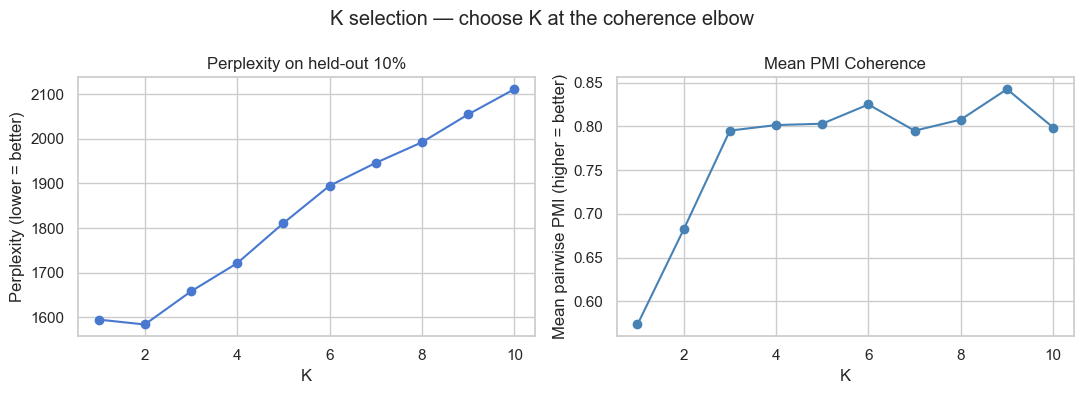

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(results_df['K'], results_df['perplexity'], marker='o')
ax1.set_title('Perplexity on held-out 10%')
ax1.set_xlabel('K')
ax1.set_ylabel('Perplexity (lower = better)')

ax2.plot(results_df['K'], results_df['coherence'], marker='o', color='steelblue')
ax2.set_title('Mean PMI Coherence')
ax2.set_xlabel('K')
ax2.set_ylabel('Mean pairwise PMI (higher = better)')

plt.suptitle('K selection — choose K at the coherence elbow')
plt.tight_layout()
plt.show()

## 3. Fit Final Model

Set `K_FINAL` based on the plot above.

In [33]:
K_FINAL = 4  

lda = LatentDirichletAllocation(
    n_components=K_FINAL, learning_method='batch', max_iter=100, random_state=42
)
lda.fit(dtm)

print(f'Final model: K={K_FINAL}, held-out perplexity={lda.perplexity(X_test):.1f}')

Final model: K=4, held-out perplexity=1704.8


In [8]:
# phi   : (K, V) normalized topic-word matrix
# theta : (N, K) document-topic distribution
phi   = lda.components_ / lda.components_.sum(axis=1, keepdims=True)
theta = lda.transform(dtm)

print(f'phi   shape : {phi.shape}')
print(f'theta shape : {theta.shape}')
print(f'theta row-sum check (should be ~1.0): {theta.sum(axis=1).mean():.4f}')

phi   shape : (4, 6745)
theta shape : (63298, 4)
theta row-sum check (should be ~1.0): 1.0000


## 4. Topic Profiling

For each topic: top words + top 5 documents by theta loading. Read the documents — do not rely on words alone. Fill in the annotation table below.

In [22]:
N_TOP_WORDS = 20
vocab_list  = list(vocab)

print('Top words per topic')
print('=' * 70)
for k in range(K_FINAL):
    top_idx   = phi[k].argsort()[::-1][:N_TOP_WORDS]
    top_words = ', '.join(vocab_list[i] for i in top_idx)
    print(f'Topic {k:2d}: {top_words}')

Top words per topic
Topic  0: people, thing, experience, think, believe, know, feel, life, time, paranormal, happen, real, way, spirit, dream, energy, see, world, demon, ghost
Topic  1: look, see, sound, light, cat, hear, think, eye, camera, black, photo, thing, picture, area, dog, maybe, video, white, time, people
Topic  2: know, spirit, good, want, help, try, people, story, thing, thank, post, find, ask, think, need, tell, read, say, work, ghost
Topic  3: time, house, room, year, see, night, happen, hear, feel, get, day, say, sleep, old, tell, door, come, think, know, walk


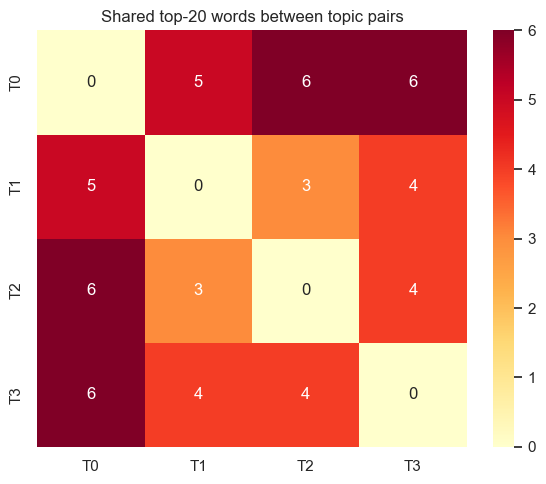


Shared words (top-20) per pair:
  T0 ∩ T1 (5): people, see, thing, think, time
  T0 ∩ T2 (6): ghost, know, people, spirit, thing, think
  T0 ∩ T3 (6): feel, happen, know, see, think, time
  T1 ∩ T2 (3): people, thing, think
  T1 ∩ T3 (4): hear, see, think, time
  T2 ∩ T3 (4): know, say, tell, think


In [23]:
import itertools

N_TOP = 20  # top words per topic to compare

# Get top-N word sets per topic
top_word_sets = {}
for k in range(K_FINAL):
    top_idx = phi[k].argsort()[::-1][:N_TOP]
    top_word_sets[k] = set(vocab_list[i] for i in top_idx)

# Pairwise overlap matrix
overlap = np.zeros((K_FINAL, K_FINAL), dtype=int)
for i, j in itertools.combinations(range(K_FINAL), 2):
    shared = top_word_sets[i] & top_word_sets[j]
    overlap[i, j] = len(shared)
    overlap[j, i] = len(shared)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    overlap, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=[f'T{k}' for k in range(K_FINAL)],
    yticklabels=[f'T{k}' for k in range(K_FINAL)],
    ax=ax
)
ax.set_title(f'Shared top-{N_TOP} words between topic pairs')
plt.tight_layout()
plt.show()

# Print which words are shared per pair
print(f'\nShared words (top-{N_TOP}) per pair:')
for i, j in itertools.combinations(range(K_FINAL), 2):
    shared = sorted(top_word_sets[i] & top_word_sets[j])
    print(f'  T{i} ∩ T{j} ({len(shared)}): {", ".join(shared) if shared else "none"}')


### FREX — Frequency × Exclusivity

Top words by raw probability alone are dominated by corpus-wide filler (*think*, *see*, *people*).
FREX re-ranks words by the harmonic mean of two ECDF-normalised scores:

- **Frequency** `phi[k, w]` — probability of the word within the topic  
- **Exclusivity** `phi[k, w] / Σ_k phi[k, w]` — share of the word's total mass in this topic

A word scores high only when it is *both* common in the topic *and* concentrated there.
`w` (default 0.5) trades off the two components.


In [14]:
from scipy.stats import rankdata

vocab_list = list(vocab) 

def frex(phi, w=0.5, n_top=15):
    """
    phi   : (K, V) row-normalised topic-word matrix
    w     : weight on frequency (1-w goes to exclusivity)
    returns frex_scores (K, V) and top word indices (K, n_top)
    """
    K, V = phi.shape

    # Exclusivity: fraction of word's total mass in each topic
    col_sums = phi.sum(axis=0)                          # (V,)
    excl = phi / np.where(col_sums > 0, col_sums, 1)   # (K, V)

    # ECDF-normalise within each topic (rank / V)
    freq_ecdf = np.apply_along_axis(
        lambda row: rankdata(row) / V, axis=1, arr=phi
    )
    excl_ecdf = np.apply_along_axis(
        lambda row: rankdata(row) / V, axis=1, arr=excl
    )

    # Harmonic mean of the two ECDF scores
    scores = 1.0 / (w / freq_ecdf + (1 - w) / excl_ecdf)

    top_idx = scores.argsort(axis=1)[:, ::-1][:, :n_top]
    return scores, top_idx


N_FREX   = 15
FREX_W   = 0.5   # 0.5 = balanced; closer to 1 = favour frequency

frex_scores, frex_top = frex(phi, w=FREX_W, n_top=N_FREX)

print(f'FREX top-{N_FREX} words per topic  (w={FREX_W})')
print('=' * 70)
for k in range(K_FINAL):
    words = ', '.join(vocab_list[i] for i in frex_top[k])
    print(f'Topic {k}: {words}')



FREX top-15 words per topic  (w=0.5)
Topic 0: world, soul, exist, brain, mental, angel, hallucination, physical, reality, ability, health, being, science, alien, stress
Topic 1: cat, camera, photo, picture, smell, tree, wood, music, orb, radio, pic, skin, flash, color, capture
Topic 2: thank, pray, board, book, sage, prayer, priest, bless, advice, protection, luck, salt, curse, cleanse, witch
Topic 3: room, walk, bed, wake, mom, ago, sit, dad, month, week, parent, sister, brother, bedroom, asleep


In [13]:
# --- side-by-side comparison: raw top-10 vs FREX top-10 ---
N_CMP = 10
cols = pd.MultiIndex.from_product(
    [[f'Topic {k}' for k in range(K_FINAL)], ['Raw', 'FREX']]
)
data = {}
for k in range(K_FINAL):
    raw_words  = [vocab_list[i] for i in phi[k].argsort()[::-1][:N_CMP]]
    frex_words = [vocab_list[i] for i in frex_top[k][:N_CMP]]
    data[(f'Topic {k}', 'Raw')]  = raw_words
    data[(f'Topic {k}', 'FREX')] = frex_words

cmp_df = pd.DataFrame(data, index=range(1, N_CMP + 1))
cmp_df.index.name = 'Rank'
cmp_df



Topic 0                Topic 1          Topic 2             Topic 3  \
             Raw           FREX     Raw     FREX     Raw        FREX     Raw   
Rank                                                                           
1         people          world    look      cat    know       thank    time   
2          thing           soul     see   camera  spirit        pray   house   
3     experience          exist   sound    photo    good       board    room   
4          think          brain   light  picture    want        book    year   
5        believe         mental     cat    smell    help        sage     see   
6           know          angel    hear     tree     try      prayer   night   
7           feel  hallucination   think     wood  people      priest  happen   
8           life       physical     eye    music   story       bless    hear   
9           time        reality  camera      orb   thing      advice    feel   
10    paranormal        ability   black    radio   thank  protection     get   

             
       FREX  
Rank         
1      room  
2      walk  
3       bed  
4      wake  
5       mom  
6       ago  
7       sit  
8       dad  
9     month  
10     week

### Doc inspection

In [21]:
N_TOP_DOCS = 5

for k in range(K_FINAL):
    print('=' * 70)
    print(f'TOPIC {k} — top {N_TOP_DOCS} documents')
    print('=' * 70)
    top_doc_idx = theta[:, k].argsort()[::-1][:N_TOP_DOCS]
    for rank, idx in enumerate(top_doc_idx, start=1):
        row     = df.iloc[idx]
        loading = theta[idx, k]
        snippet = row['text_clean']
        date    = str(row.get('date', row.get('year_month', '')))
        print(f'  [{rank}] theta={loading:.3f} | {date}')
        print(textwrap.fill(snippet, width=76, initial_indent='      ', subsequent_indent='      '))
        print()
    print()

TOPIC 0 — top 5 documents
  [1] theta=0.990 | 2025-02-04 00:00:00
      You might find comfort in reading about near-death experiences (NDEs),
      which many people across different cultures and religions have
      reported. Some describe feelings of immense love and peace, meeting
      deceased loved ones, or encountering a divine presence. While skeptics
      argue these experiences are brain-related phenomena, others see them
      as glimpses into an afterlife. There are also accounts from hospice
      workers who witness patients speaking to unseen loved ones before
      passing, or children recalling details of past lives they couldn’t
      have known. While none of this constitutes scientific proof, these
      stories suggest that consciousness may continue in some form beyond
      death. Your fear of nothingness is understandable. Even if we don’t
      have absolute certainty, there’s reason to believe death isn’t the
      end. Whether through faith, personal experi

Topic 0: associated with health and mental health


In [26]:
N_SAMPLE    = 5
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

W = 82  # paragraph wrap width

for k in range(K_FINAL):
    print('\n' + '─' * W)
    print(f'  TOPIC {k} — {N_SAMPLE} proportionally sampled documents')
    print('─' * W)

    dominant   = theta.argmax(axis=1)                        # hard assignment
    members    = np.where(dominant == k)[0]                  # docs belonging to topic k
    sample_idx = rng.choice(members, size=min(N_SAMPLE, len(members)), replace=False)

    for rank, idx in enumerate(sample_idx, start=1):
        row     = df.iloc[idx]
        loading = theta[idx, k]
        date    = str(row.get('date', row.get('year_month', '')))

        print(f'\n  [{rank}]  {row["type"].upper()}  |  {date}  |  score={row["score"]}  |  theta={loading:.3f}')
        print('  ' + '─' * (W - 2))

        full_text = str(row['text_clean'])   # no truncation
        paragraph = textwrap.fill(full_text, width=W - 4,
                                  initial_indent='  ',
                                  subsequent_indent='  ')
        print(paragraph)
        print()

    print('─' * W + '\n')




──────────────────────────────────────────────────────────────────────────────────
  TOPIC 0 — 5 proportionally sampled documents
──────────────────────────────────────────────────────────────────────────────────

  [1]  COMMENT  |  2025-02-01 00:00:00  |  score=0  |  theta=0.519
  ────────────────────────────────────────────────────────────────────────────────
  Ok, I see how you got there. On that I won't advise either way because I
  feel that's a personal choice. For me, no. But not all the information are
  lost souls needing help. Being able to recognize & filter makes it a choice.
  If you (gonna stipulate to the use of general you for ease of typing) are
  just picking up remnants of pain, then why do it, who does it help? To me
  acknowledging that pain & praying for it is enough for me. If picking up on
  that feels like you need to do more to find peace with that and does you
  good then that's the only answer needed to that why. I don't often come
  across something that n

In [27]:
N_SAMPLE    = 5
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

W = 82  # paragraph wrap width

dominant   = theta.argmax(axis=1)
is_post    = (df['type'] == 'post').values

for k in range(K_FINAL):
    print('\n' + '─' * W)
    print(f'  TOPIC {k} — {N_SAMPLE} sampled posts (dominant-member only)')
    print('─' * W)

    members    = np.where((dominant == k) & is_post)[0]
    sample_idx = rng.choice(members, size=min(N_SAMPLE, len(members)), replace=False)

    for rank, idx in enumerate(sample_idx, start=1):
        row     = df.iloc[idx]
        loading = theta[idx, k]
        date    = str(row.get('date', row.get('year_month', '')))

        print(f'\n  [{rank}]  {date}  |  score={row["score"]}  |  theta={loading:.3f}')
        print('  ' + '─' * (W - 2))

        paragraph = textwrap.fill(str(row['text_clean']), width=W - 4,
                                  initial_indent='  ',
                                  subsequent_indent='  ')
        print(paragraph)
        print()



──────────────────────────────────────────────────────────────────────────────────
  TOPIC 0 — 5 sampled posts (dominant-member only)
──────────────────────────────────────────────────────────────────────────────────

  [1]  2025-01-29 00:00:00  |  score=1  |  theta=0.568
  ────────────────────────────────────────────────────────────────────────────────
  So this happened about 4 years ago or so. I was dating a man who was an
  extreme skeptic when I have always been 100% a believer, even with only one
  personal paranormal experience before. Which is a cool story for another
  time. He and I had been dating for about 3 years at this point, and I have
  always had a rule about no pranking, scaring, or tricking my partner and
  have always been completely honest with him, and he had the same values with
  me. Despite him being a non-believer, to this day, he


  [2]  2025-03-13 00:00:00  |  score=1  |  theta=0.414
  ──────────────────────────────────────────────────────────────────────

## 5. Topic Distribution Heatmap

Mean theta per topic across the full corpus — shows which topics dominate overall.

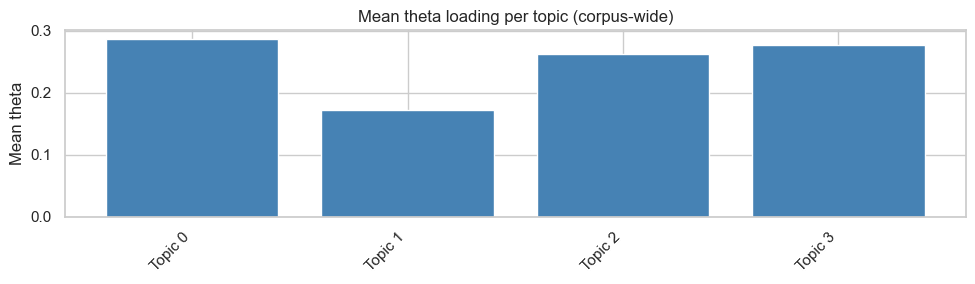

In [28]:
mean_theta = theta.mean(axis=0)
topic_labels_tmp = [f'Topic {k}' for k in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(K_FINAL), mean_theta, color='steelblue')
ax.set_xticks(range(K_FINAL))
ax.set_xticklabels(topic_labels_tmp, rotation=45, ha='right')
ax.set_title('Mean theta loading per topic (corpus-wide)')
ax.set_ylabel('Mean theta')
plt.tight_layout()
plt.show()

## 6. Score Correlation

Spearman rho between post score and each topic's theta loading. Reveals whether any topics attract more engagement. Bonferroni-corrected.

In [1]:
score_vals  = df['score'].fillna(0).values
alpha_bonf  = 0.05 / K_FINAL

print('Spearman rho: score ~ topic theta loading')
print(f'(* = Bonferroni-significant, threshold p < {alpha_bonf:.4f})')
print()
for k in range(K_FINAL):
    rho, p = spearmanr(score_vals, theta[:, k])
    sig    = '*' if p < alpha_bonf else ''
    print(f'  Topic {k:2d}: rho={rho:+.3f}  p={p:.4f}  {sig}')

NameError: name 'df' is not defined

## 7. Write Artifacts

In [27]:
np.save(ARTIFACTS / 'theta.npy', theta)
np.save(ARTIFACTS / 'phi.npy',   phi)

with open(ARTIFACTS / 'lda_vocab.json', 'w') as fh:
    json.dump(list(vocab), fh)

joblib.dump(lda, ARTIFACTS / 'lda_model.pkl')

# Fill in labels before running 04_temporal.ipynb
template = {str(k): f'Topic {k} — label here' for k in range(K_FINAL)}
with open(ARTIFACTS / 'topic_labels.json', 'w') as fh:
    json.dump(template, fh, indent=2)

print('Artifacts written:')
for name in ('theta.npy', 'phi.npy', 'lda_vocab.json', 'lda_model.pkl', 'topic_labels.json'):
    p = ARTIFACTS / name
    if p.exists():
        print(f'  {p}  ({p.stat().st_size / 1024:.1f} KB)')

print()
print('Next: fill in topic_labels.json, then run 04_temporal.ipynb.')

Artifacts written:
  artifacts\theta.npy  (1978.2 KB)
  artifacts\phi.npy  (210.9 KB)
  artifacts\lda_vocab.json  (71.4 KB)
  artifacts\lda_model.pkl  (427.7 KB)
  artifacts\topic_labels.json  (0.1 KB)

Next: fill in topic_labels.json, then run 04_temporal.ipynb.
